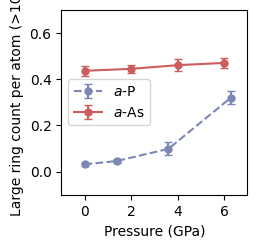

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("large_rings.csv")

df_as = df[df["system"] == "a-As"].sort_values("pressure")
df_p = df[df["system"] == "a-P"].sort_values("pressure")

labels_as = df_as["pressure"].values
means_as = df_as["mean"].values
stds_as = df_as["std"].values

labels_p = df_p["pressure"].values
means_p = df_p["mean"].values
stds_p = df_p["std"].values

fig, ax = plt.subplots(figsize=(2.4, 2.4))

finite_p = np.isfinite(means_p)
if np.any(finite_p):
    ax.errorbar(np.array(labels_p)[finite_p],
                np.array(means_p)[finite_p],
                yerr=np.array(stds_p)[finite_p],
                marker='o', linestyle='--', color='#7c87b5',
                markersize=5, capsize=3, label=r"$a$-P", zorder=3)

finite_as = np.isfinite(means_as)
if np.any(finite_as):
    ax.errorbar(np.array(labels_as)[finite_as],
                np.array(means_as)[finite_as],
                yerr=np.array(stds_as)[finite_as],
                marker='o', linestyle='-', color='#cc5d5d',
                markersize=5, capsize=3, label=r"$a$-As", zorder=1)

ax.set_xlabel("Pressure (GPa)")
ax.set_ylabel("Large ring count per atom (>10)")
ax.set_xlim(-1, 7)
ax.set_xticks(np.arange(0, 7, 2))
ax.set_ylim(-0.1, 0.7)
ax.set_yticks(np.arange(0, 0.7, 0.2))

ax.legend()
ax.yaxis.set_tick_params(which='both', labelbottom=True, bottom=True, zorder=10)
ax.xaxis.set_tick_params(which='both', labelbottom=True, bottom=True, zorder=10)

plt.show()